In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../')

from minilearn.classifiers import LogisticRegression as MiniLR
from minilearn.classifiers import GaussianNaiveBayes as MiniNB
from minilearn.classifiers import KNearestNeighbors as MiniKNN

from sklearn.linear_model import LogisticRegression as SklearnLR
from sklearn.naive_bayes import GaussianNB as SklearnNB
from sklearn.neighbors  import KNeighborsClassifier as SklearnKNN
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#load svaed train and test data
train_df = pd.read_csv('../data/train_features.csv')
test_df = pd.read_csv('../data/test_features.csv')
#serpreate features and labels
features_cols = [col for col in train_df.columns if col != "emotion"]

X_train = train_df[features_cols].values
y_train = train_df['emotion'].values

X_test = test_df[features_cols].values
y_test = test_df['emotion'].values

print(f"Traing set: {X_train.shape}")
print(f'Test set: {X_test.shape}')
print(f'Classes: {np.unique(y_train)}')




Traing set: (1961, 112)
Test set: (491, 112)
Classes: [' fearful' 'angry' 'calm' 'disgust' 'happy' 'neutral' 'sad' 'surprised']


In [2]:
# Fixing the space in ' fearful'

y_train = np.array([label.strip() for label in y_train])
y_test = np.array([label.strip() for label in y_test])

print(f"classes after fix: {np.unique(y_train)}")

classes after fix: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']


In [3]:
print("Training Minilearn Logistic Regression")
mini_lr = MiniLR(learning_rate=0.01, n_iterations=1000)
mini_lr.fit(X_train, y_train)
mini_lr_preds = mini_lr.predict(X_test)
mini_lr_acc = accuracy_score(y_test, mini_lr_preds)
print(f'MiniLearn Logistic Regression Accuracy: {mini_lr_acc:.4f}')

print("\nTraining MiniLearn Naive Bayes")
mini_nb = MiniNB()
mini_nb.fit(X_train, y_train)
mini_nb_preds = mini_nb.predict(X_test)
mini_nb_acc = accuracy_score(y_test, mini_nb_preds)
print(f"Minilearn Naive Bayes Accuracy: {mini_nb_acc:.4f}")

print("\nTraining MiniLearn KNN")
mini_knn=MiniKNN(k=5)
mini_knn.fit(X_train, y_train)
mini_knn_preds = mini_knn.predict(X_test)
mini_knn_acc = accuracy_score(y_test, mini_knn_preds)
print(f'MiniLearn Knn Accuracy: {mini_knn_acc:.4f}')

Training Minilearn Logistic Regression
MiniLearn Logistic Regression Accuracy: 0.5947

Training MiniLearn Naive Bayes
Minilearn Naive Bayes Accuracy: 0.4094

Training MiniLearn KNN
MiniLearn Knn Accuracy: 0.5825


In [4]:
#train the sklearn models

print("Training SkLearn Logistic Regression")
sklearn_lr = SklearnLR(max_iter=1000)
sklearn_lr.fit(X_train,y_train)
sklearn_lr_acc = accuracy_score(y_test, sklearn_lr.predict(X_test))
print(f"Sklearn Logistic Regression Accuracy: {sklearn_lr_acc:.4f}")

print("\nTraining Sklearn Naive Bayes")
sklearn_nb = SklearnNB()
sklearn_nb.fit(X_train, y_train)
sklearn_nb_acc = accuracy_score(y_test, sklearn_nb.predict(X_test))
print(f'Sklearn Naive Bayes ACcuracy: {sklearn_nb_acc:.4f}')

print('\nTraing Sklearn KNN')
sklearn_knn = SklearnKNN(n_neighbors=5)
sklearn_knn.fit(X_train, y_train)
sklearn_knn_acc = accuracy_score(y_test, sklearn_knn.predict(X_test))
print(f"Sklearn KNN Accurcy: {sklearn_knn_acc:.4f}")

Training SkLearn Logistic Regression
Sklearn Logistic Regression Accuracy: 0.6660

Training Sklearn Naive Bayes
Sklearn Naive Bayes ACcuracy: 0.4073

Traing Sklearn KNN
Sklearn KNN Accurcy: 0.5723


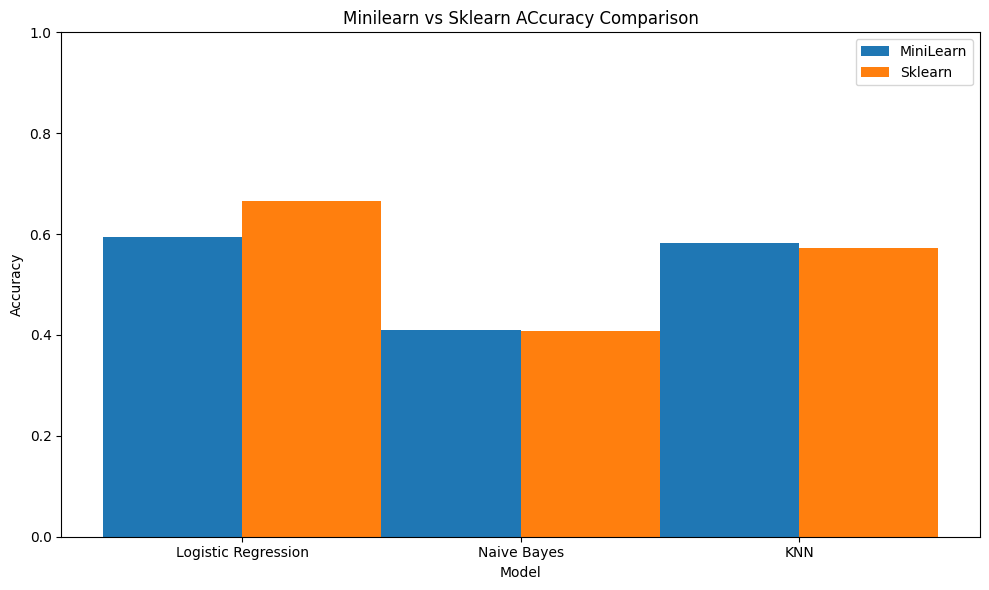

In [ ]:
#comparison bar chart
models = ['Logistic Regression', 'Naive Bayes', 'KNN']
minilearn_scores = [mini_lr_acc, mini_nb_acc, mini_knn_acc]
sklearn_scores = [ sklearn_lr_acc, sklearn_nb_acc, sklearn_knn_acc]

x = np.arange(len(models))
width=0.5

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x-width/2, minilearn_scores, width, label='MiniLearn')
ax.bar(x+ width/2, sklearn_scores, width, label='Sklearn')

ax.set_xlabel("Model")
ax.set_ylabel('Accuracy')
ax.set_title('Minilearn vs Sklearn Accuracy Comparison')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0,1)
plt.tight_layout()
plt.show()


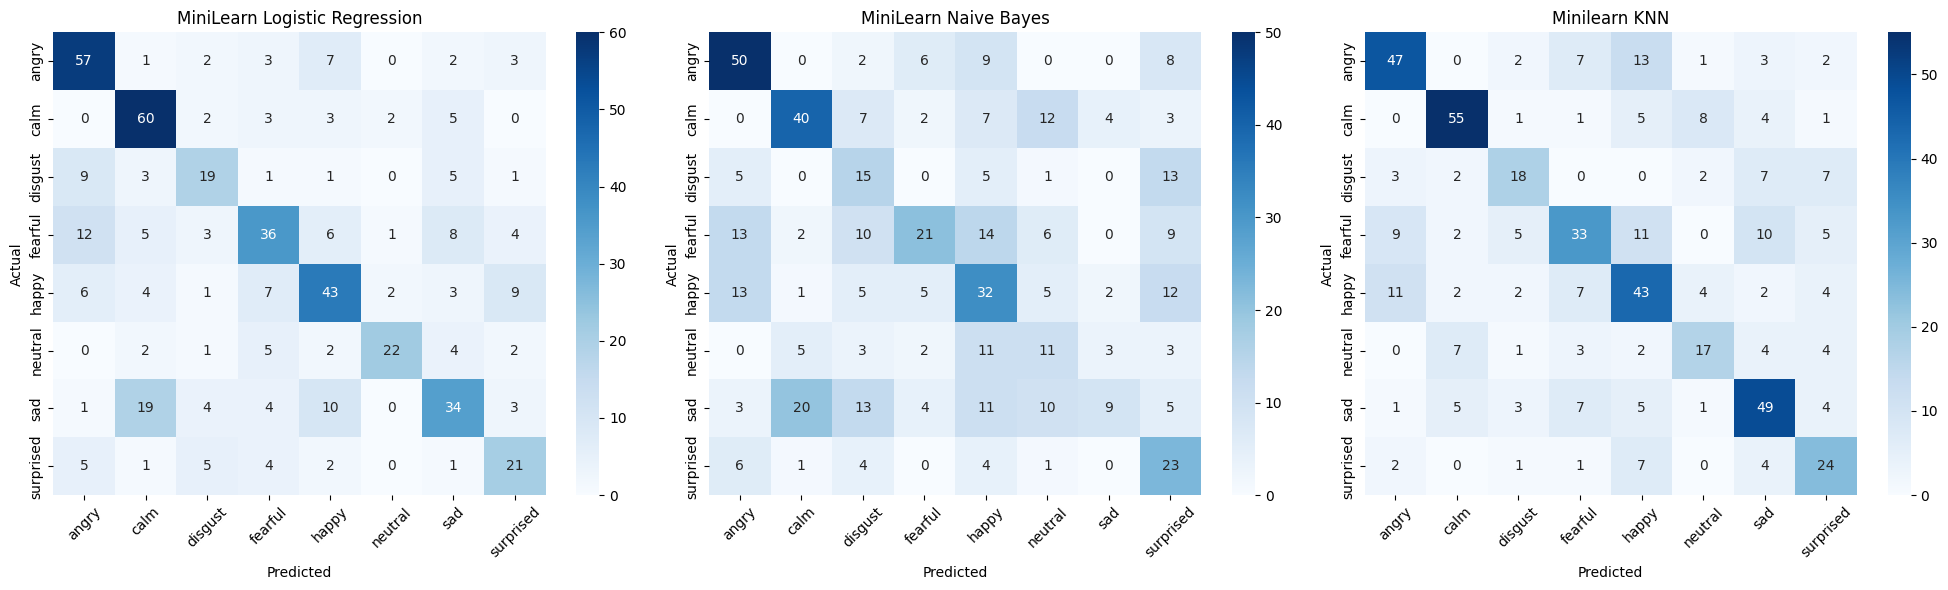

In [11]:
#confusion matrices for mini learn models
fig, axes = plt.subplots(1,3,figsize=(20,6))

classes = np.unique(y_test)

cm_lr = confusion_matrix(y_test, mini_lr_preds, labels=classes)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap="Blues", xticklabels=classes, yticklabels=classes, ax=axes[0])
axes[0].set_title('MiniLearn Logistic Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].tick_params(axis='x', rotation=45)

#minilearn naive bayes
cm_nb = confusion_matrix(y_test, mini_nb_preds, labels=classes)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap="Blues", xticklabels=classes, yticklabels=classes, ax=axes[1])
axes[1].set_title('MiniLearn Naive Bayes')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].tick_params(axis='x', rotation=45)

#minilearn KNN
cm_knn = confusion_matrix(y_test, mini_knn_preds, labels=classes)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap="Blues", xticklabels=classes, yticklabels=classes, ax=axes[2])
axes[2].set_title("Minilearn KNN")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel('Actual')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()



In [9]:
print("MiniLearn Logistic Regression Classification Report")
print(classification_report(y_test, mini_lr_preds))

print("Sklearn Logistic Regression Classification Report")
print(classification_report(y_test, sklearn_lr.predict(X_test)))


MiniLearn Logistic Regression Classification Report
              precision    recall  f1-score   support

       angry       0.63      0.76      0.69        75
        calm       0.63      0.80      0.71        75
     disgust       0.51      0.49      0.50        39
     fearful       0.57      0.48      0.52        75
       happy       0.58      0.57      0.58        75
     neutral       0.81      0.58      0.68        38
         sad       0.55      0.45      0.50        75
   surprised       0.49      0.54      0.51        39

    accuracy                           0.59       491
   macro avg       0.60      0.58      0.59       491
weighted avg       0.60      0.59      0.59       491

Sklearn Logistic Regression Classification Report
              precision    recall  f1-score   support

       angry       0.73      0.72      0.72        75
        calm       0.70      0.77      0.73        75
     disgust       0.71      0.62      0.66        39
     fearful       0.65      0

Week 7 Reflection

Implemented Logistic Regression, Gaussian Naive Bayes, and K nearest Neighbor and compared them to sklearn models

MiniLearn LR Vs Sklearn LR = 59.7% | 66.60%
MiniLearn NB Vs SKlearn NB = 40.94% | 40.73%
MiniLearn KNN Vs Sklearn KNN = 58.25% | 57.23%

Logistic Regression was the best preforming Minilearn model however it was also the worse model when compared to Sklearn with a difference of 7%. I think this difference is because Sklearn has a much more optimized techniques compared to my relivitly simple gradient descent implementation. both models struggled with disgust and sad which had the lowest F1 scores of 0.5 while calm and angry were the easiest emotions to classify with f1 scores of 0.71 and 0.69 respectively.

Naive Bayes was the weakest model for both sklearn and my minilearn implementation. however it did perform far better than randomly guessing which would have been 12.5 percent. it was expected that this model would preform the worse because NB assumings all features are completely independent of eachother which is not the case for these audio features. my mini learn was very similar in percent success to sklearn which confirms that its not low because my code is wrong but because this is just not a great model for the task.

KNN with k=5 performed very simliarly to my LR model. and my implemetation slightly out performed the sklearn model 58.25% vs 57.23% which confirms the KNN is a simple and straightforward enough implemetnation to get similar results from a model made from scratch compared to sklearn. 

if you look at the confusion matrices  and classification reports the hardest emotions to classify for the models were Fearful, Disgust, suprised, and neutral. this is mostlikely because the emotions with similar energy levels and acoutisc properties are naturally harder for the models to distingush

Overall my models performed very similar and even better than sklearn with the expection of LR because of the difference in optimizations however its learn if we want higher performance percents we need to make more advanced models like neural networks or SVM. 


